# Merging Sentinel inputs with binary tree labels

``merge_inputs_outputs`` combines a Sentinel-2 pickle with a binary tree-cover
tif to produce a per-pixel training CSV. Each row is one sampled pixel, and
columns are temporally-aggregated Sentinel features (median, std, focal
mean, focal std per band) plus vegetation indices and the binary tree label.

In [1]:
import pickle
import rioxarray as rxr

from shelterbelts.classifications.merge_inputs_outputs import merge_inputs_outputs, jittered_grid, aggregated_metrics, visualise_jittered_grid
from shelterbelts.utils.filepaths import get_filename

## Example Inputs

In [2]:
sentinel_pickle = get_filename('g2_019_sentinel_150mx150m.pkl')
tree_tif = get_filename('g2_019_binary_trees_150mx150m.tiff')

with open(sentinel_pickle, 'rb') as f:
    ds = pickle.load(f)
ds

<xarray.Dataset> Size: 337kB
Dimensions:           (time: 33, y: 15, x: 17)
Coordinates:
  * time              (time) datetime64[ns] 264B 2020-01-10T00:06:22.308020 ....
  * y                 (y) float64 120B -4.205e+06 -4.205e+06 ... -4.205e+06
  * x                 (x) float64 136B 1.661e+07 1.661e+07 ... 1.661e+07
    spatial_ref       int32 4B 3857
Data variables:
    nbart_blue        (time, y, x) float32 34kB 1.008e+03 1.008e+03 ... 403.0
    nbart_green       (time, y, x) float32 34kB 1.355e+03 1.355e+03 ... 648.0
    nbart_red         (time, y, x) float32 34kB 1.942e+03 1.942e+03 ... 717.0
    nbart_red_edge_1  (time, y, x) float32 34kB 2.132e+03 ... 1.141e+03
    nbart_red_edge_2  (time, y, x) float32 34kB 2.253e+03 ... 1.815e+03
    nbart_red_edge_3  (time, y, x) float32 34kB 2.59e+03 2.59e+03 ... 2.11e+03
    nbart_nir_1       (time, y, x) float32 34kB 2.886e+03 ... 2.487e+03
    nbart_nir_2       (time, y, x) float32 34kB 2.912e+03 ... 2.505e+03
    nbart_swir_2      (time, y, x) float32 34kB 3.831e+03 ... 2.132e+03
    nbart_swir_3      (time, y, x) float32 34kB 2.883e+03 ... 1.224e+03
Attributes:
    crs:           EPSG:3857
    grid_mapping:  spatial_ref

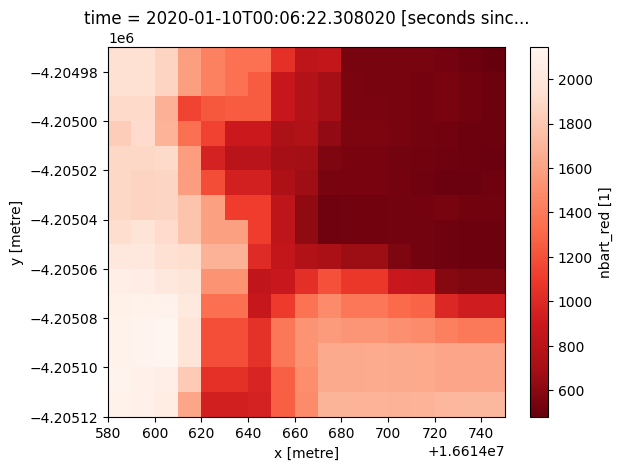

In [3]:
# Example imagery (red band)
ds['nbart_red'].isel(time=0).plot(cmap='Reds_r')

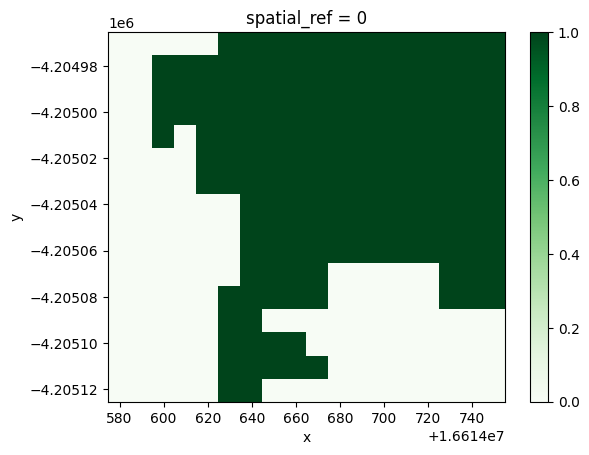

In [4]:
# Ground truth binary tree raster
da = rxr.open_rasterio(tree_tif).isel(band=0).drop_vars('band')
da.plot(cmap='Greens')

## Merge into a training CSV

In [5]:
df = merge_inputs_outputs(
    sentinel_pickle,
    tree_tif,
    outdir='outdir',
    spacing=3,   # default spacing=10 is designed for 1km tiles; use 3 for this 150m demo tile
)
df

Saved: outdir/g2_019_binary_trees_150mx150m_df_r4_s3_2020.csv


,tree_cover,nbart_blue_temporal_median,nbart_blue_temporal_std,nbart_blue_focal_mean,nbart_blue_focal_std,nbart_green_temporal_median,nbart_green_temporal_std,nbart_green_focal_mean,nbart_green_focal_std,nbart_red_temporal_median,...,NDVI_focal_mean,NDVI_focal_std,GRNDVI_temporal_median,GRNDVI_temporal_std,GRNDVI_focal_mean,GRNDVI_focal_std,y,x,tile_id,year
0,0.0,453.0,232.246414,-230.148148,499.143951,771.0,240.784897,-90.271606,603.331787,639.0,...,0.388791,0.246216,0.690691,7.854658e-02,0.535271,0.126560,-4204970.5,16614590.0,g2_019_binary_trees_150mx150m,2020
1,1.0,272.0,188.256760,375.407410,57.808952,402.0,219.675797,571.617310,108.150841,382.0,...,0.639295,0.071024,0.705647,5.577413e-02,0.675557,0.029496,-4204980.5,16614630.0,g2_019_binary_trees_150mx150m,2020
2,1.0,341.0,161.291183,359.382721,54.126904,482.0,171.854935,536.074097,90.171761,493.0,...,0.638904,0.073225,0.648391,4.513824e-02,0.676751,0.030742,-4204970.5,16614640.0,g2_019_binary_trees_150mx150m,2020
3,1.0,248.0,105.672752,276.456787,90.431061,364.0,98.248718,399.555573,100.979607,328.0,...,0.664829,0.087521,0.703369,3.959333e-02,0.689320,0.037166,-4204980.5,16614680.0,g2_019_binary_trees_150mx150m,2020
4,1.0,198.0,111.101410,216.864197,27.093981,315.0,99.766220,332.802460,28.698030,232.0,...,0.734357,0.036490,0.721416,4.946087e-02,0.719996,0.012982,-4204980.5,16614710.0,g2_019_binary_trees_150mx150m,2020
5,1.0,198.0,111.013000,192.271606,6.966931,309.0,98.623589,308.691345,7.579048,232.0,...,0.770716,0.009489,0.735481,4.995719e-02,0.731932,0.005390,-4204990.5,16614740.0,g2_019_binary_trees_150mx150m,2020
6,0.0,-999.0,0.000000,-374.160492,551.243530,-999.0,0.000000,-249.234573,672.147278,-999.0,...,0.298248,0.266309,0.333333,5.960464e-08,0.489085,0.136883,-4205000.5,16614580.0,g2_019_binary_trees_150mx150m,2020
7,1.0,311.0,151.736862,377.419769,67.525055,443.0,152.750244,577.679016,131.830902,396.0,...,0.618770,0.057008,0.675653,5.618643e-02,0.669087,0.025932,-4205020.5,16614630.0,g2_019_binary_trees_150mx150m,2020
8,1.0,388.0,105.602463,344.592590,54.144360,554.0,90.583855,516.506165,93.860489,557.0,...,0.634529,0.062221,0.682940,3.780150e-02,0.675502,0.030023,-4205000.5,16614640.0,g2_019_binary_trees_150mx150m,2020
9,1.0,189.0,112.441536,248.049393,68.502846,309.0,102.333717,364.370361,73.119202,229.0,...,0.693634,0.073683,0.719187,5.025366e-02,0.702215,0.028336,-4205000.5,16614690.0,g2_019_binary_trees_150mx150m,2020


## Visualise the sampling grid

``merge_inputs_outputs`` uses the function ``jittered_grid`` to sample pixels at regular intervals with small random
offsets. We can visualise this sampling by calling jittered_grid directly.

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

with open(sentinel_pickle, 'rb') as f:
    ds = pickle.load(f)

da = rxr.open_rasterio(tree_tif).isel(band=0).drop_vars('band')
ds = ds.rio.reproject_match(da)
ds['tree_cover'] = da.astype(float)

visualise_jittered_grid(ds, spacing=3, stub='g2_019_150mx150m')  # Can view this output in QGIS

Saved:  /scratch/xe2/cb8590/tmp/g2_019_150mx150m_jittered_s3.gpkg


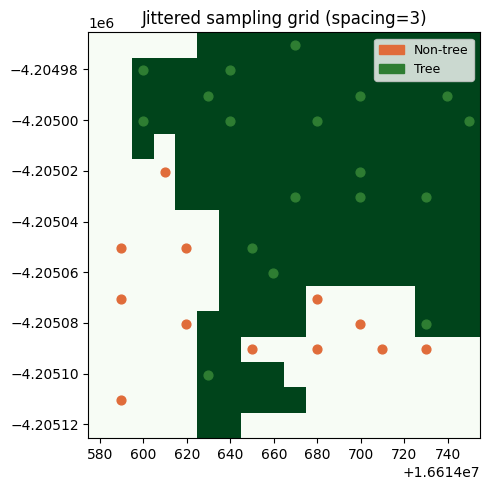

In [7]:
# Example plot
grid_df = jittered_grid(ds, spacing=3)

fig, ax = plt.subplots(figsize=(5, 5))
da.plot(ax=ax, cmap='Greens', add_colorbar=False)

colors = {0.0: '#e06c3a', 1.0: '#2e7d32'}
for label, group in grid_df.groupby('tree_cover'):
    ax.scatter(group['x'], group['y'], color=colors[label], s=40, zorder=3)

patches = [
    mpatches.Patch(color=colors[0.0], label='Non-tree'),
    mpatches.Patch(color=colors[1.0], label='Tree'),
]
ax.legend(handles=patches, loc='upper right', fontsize=9)
ax.set_title('Jittered sampling grid (spacing=3)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()